<a href="https://colab.research.google.com/github/NBK-code/Reinforcement_Learning/blob/main/Deep_Q_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import gymnasium as gym
from IPython.display import Video

In [2]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning, module='moviepy')

In [ ]:
!pip install swig
!pip install "gymnasium[box2d]"

In [12]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

env = gym.wrappers.RecordVideo(env,
                               video_folder="./savevideos",
                               disable_logger=True,
                               name_prefix="sample")

done = False
_ = env.reset(seed=42)
while not done:
    state, reward, done, _, _ = env.step(env.action_space.sample())
env.close()

Video("savevideos/sample-episode-0.mp4", embed=True)

In [13]:
state

array([ 0.16280833, -0.0323961 ,  0.15424211, -0.8612169 ,  0.12625195,
       -5.4244165 ,  0.        ,  1.        ], dtype=float32)

The state is given by

 - X Coordinate of the Lander
 - Y Coordinate of the Lander
 - Velocity in X Direction
 - Velocity in Y Direction
 - Angle
 - Angular Velocity
 - Is the Left Leg Touching the Ground
 - Is the Right Leg Touching the Ground

In [16]:
env.action_space

Discrete(4)

We have 4 possible actions that we can pick from:

 - 0: Do Nothing
 - 1: Fire Left Engine
 - 2: Fire Main Engine
 - 3: Fire Right Engine

In [14]:
reward

-100

For each step, the reward:

 - is increased/decreased the closer/further the lander is to the landing pad.
 - is increased/decreased the slower/faster the lander is moving.
 - is decreased the more the lander is tilted (angle not horizontal).
 - is increased by 10 points for each leg that is in contact with the ground.
 - is decreased by 0.03 points each frame a side engine is firing.
 - is decreased by 0.3 points each frame the main engine is firing.

The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively. An episode is considered a solution if it scores at least 200 points.

In [18]:
class DQN(nn.Module):
    def __init__(self,
                 input_state_features=8,
                 num_actions=4,
                 hidden_features=128):

        super(DQN, self).__init__()

        self.fc1 = nn.Linear(input_state_features, hidden_features)
        self.fc2 = nn.Linear(hidden_features,hidden_features)
        self.fc3 = nn.Linear(hidden_features, num_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [19]:
class TimeCapsule:

    def __init__(self, max_memories, num_state_features=8):

        self.max_memories = max_memories
        self.current_memories_counter = 0

        self.state_memory = torch.zeros((self.max_memories, num_state_features), dtype=torch.float32)
        self.next_state_memory = torch.zeros((self.max_memories, num_state_features), dtype=torch.float32)
        self.action_memory = torch.zeros((self.max_memories, ), dtype=torch.long)
        self.reward_memory = torch.zeros((self.max_memories, ), dtype=torch.float32)
        self.terminal_memory = torch.zeros((self.max_memories, ), dtype=torch.bool)

    def add_memory(self, state, next_state, action, reward, terminal):

        idx = self.current_memories_counter % self.max_memories
        self.state_memory[idx] = torch.tensor(state, dtype=self.state_memory.dtype)
        self.next_state_memory[idx] = torch.tensor(next_state, dtype=self.next_state_memory.dtype)
        self.action_memory[idx] = torch.tensor(action, dtype=self.action_memory.dtype)
        self.reward_memory[idx] = torch.tensor(reward, dtype=self.reward_memory.dtype)
        self.terminal_memory[idx] = torch.tensor(terminal, dtype=self.terminal_memory.dtype)

        self.current_memories_counter += 1

    def access_memories(self, batch_size, device="cpu"):

        total_memories = min(self.current_memories_counter, self.max_memories)

        if total_memories < batch_size:
            return None

        rand_sample_idx = np.random.choice(np.arange(total_memories), size=batch_size, replace=False)
        rand_sample_idx = torch.tensor(rand_sample_idx, dtype=torch.long)

        batch = {"states": self.state_memory[rand_sample_idx].to(device),
                 "next_states": self.next_state_memory[rand_sample_idx].to(device),
                 "actions": self.action_memory[rand_sample_idx].to(device),
                 "rewards": self.reward_memory[rand_sample_idx].to(device),
                 "terminal": self.terminal_memory[rand_sample_idx].to(device)}

        return batch

In [20]:
class Agent:
    def __init__(self,
                 max_memories=100_000,
                 discount_factor=0.99,
                 learning_rate=0.001,
                 input_state_features=8,
                 num_actions=4,
                 hidden_features=128,
                 epsilon=1.0,
                 epsilon_decay=0.999,
                 min_epsilon=0.05,
                 device="cpu"):

        self.max_memories = max_memories
        self.discount_factor = discount_factor
        self.learning_rate = learning_rate
        self.input_state_features = input_state_features
        self.num_actions = num_actions
        self.action_space = np.arange(self.num_actions)
        self.hidden_features = hidden_features
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.device = device

        self.DQN = DQN(self.input_state_features, self.num_actions, self.hidden_features).to(device)
        self.optimizer = optim.Adam(self.DQN.parameters(), lr=self.learning_rate)
        self.loss_fn = nn.MSELoss()
        self.timecapsule = TimeCapsule(self.max_memories, self.input_state_features)

    def select_action(self, state):

        if not isinstance(state, torch.Tensor):
            state = torch.tensor(state, device=self.device)

        if state.dim() == 1:
            state = state.unsqueeze(0)

        assert state.shape[-1] == self.input_state_features, f"Passing {state.shape[-1]} features, expect {self.input_state_features}"

        if np.random.rand() < self.epsilon:
            action = np.random.choice(self.action_space)
        else:
            self.DQN.eval()
            with torch.no_grad():
                Q_s_a = self.DQN(state)
            action = torch.argmax(Q_s_a).item()
            self.DQN.train()

        return action

    def update_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

    def inference(self, state, device="cpu"):

        self.DQN = self.DQN.to(device)
        self.DQN.eval()

        with torch.no_grad():
            Q_s_a = self.DQN(state.to(device))

        return torch.argmax(Q_s_a).item()

    def train_step(self, batch_size):

        batch = self.timecapsule.access_memories(batch_size, self.device)

        if batch is None:
            return None

        q_estimate = self.DQN(batch["states"])  ### [B x Actions]
        q_estimate = torch.gather(q_estimate, index=batch["actions"].unsqueeze(-1), dim=-1).squeeze(-1) ###[B]

        with torch.no_grad():
            self.DQN.eval()
            q_next_estimate = self.DQN(batch["next_states"])  ### [B x Actions]
            self.DQN.train()

        max_q_next_estimate = torch.max(q_next_estimate, dim=-1).values ###[B]
        td_target = batch["rewards"] + self.discount_factor * max_q_next_estimate * (~batch["terminal"])

        loss = self.loss_fn(td_target, q_estimate)

        loss.backward()
        self.optimizer.step()
        self.optimizer.zero_grad()
        self.update_epsilon()

In [21]:
def trainer(env,
            num_games=500,
            min_reward=200,
            game_tolerance=10,
            max_memories=100_000,
            discount_factor=0.99,
            learning_rate=0.001,
            batch_size=64,
            input_state_features=8,
            num_actions=4,
            hidden_features=128,
            epsilon=1.0,
            epsilon_decay=0.999,
            min_epsilon=0.05,
            log_freq=5,
            running_avg_steps=25,
            device="cpu"):

  agent = Agent(max_memories=max_memories,
                  discount_factor=discount_factor,
                  learning_rate=learning_rate,
                  input_state_features=input_state_features,
                  num_actions=num_actions,
                  hidden_features=hidden_features,
                  epsilon=epsilon,
                  epsilon_decay=epsilon_decay,
                  min_epsilon=min_epsilon,
                  device=device)

  ending_tol = 0

  log = {"scores": [], "running_avg_scores": []}

  for i in range(num_games):
        score = 0
        state, _ = env.reset()
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminal, truncated, _= env.step(action)
            done = terminal or truncated
            score += reward
            agent.timecapsule.add_memory(state, next_state, action, reward, done)
            agent.train_step(batch_size)
            state = next_state

        log["scores"].append(score)
        running_avg_score = np.mean(log["scores"][-running_avg_steps:])
        log["running_avg_scores"].append(running_avg_score)

        if i % log_freq == 0:
            print(f"Game #: {i} | Score: {score} | Moving Avg Scores: {running_avg_score} | Epsilon: {agent.epsilon}")

        if score >= min_reward:
            ending_tol += 1

            if ending_tol == game_tolerance:
                break
        else:
            ending_tol = 0

  print("Completed Training")
  return agent, log

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
agent, log = trainer(env, device=device)

Game #: 0 | Score: -354.5114824668884 | Moving Avg Scores: -354.5114824668884 | Epsilon: 0.9636582956114175
Game #: 5 | Score: -26.169712869294344 | Moving Avg Scores: -221.18009598683048 | Epsilon: 0.5276512561805725
Game #: 10 | Score: -187.22831893861013 | Moving Avg Scores: -174.53157678590466 | Epsilon: 0.2454400717794207
Game #: 15 | Score: -113.03269827448166 | Moving Avg Scores: -193.70075555047254 | Epsilon: 0.10165777415071181
Game #: 20 | Score: -107.85129345264686 | Moving Avg Scores: -191.33546514459815 | Epsilon: 0.05
Game #: 25 | Score: -53.0850706630349 | Moving Avg Scores: -167.2300255631121 | Epsilon: 0.05
Game #: 30 | Score: -93.59383725417875 | Moving Avg Scores: -146.27362682536358 | Epsilon: 0.05
Game #: 35 | Score: -79.3061539348633 | Moving Avg Scores: -137.25500786467444 | Epsilon: 0.05
Game #: 40 | Score: -49.28047708167922 | Moving Avg Scores: -104.49575143066184 | Epsilon: 0.05
Game #: 45 | Score: -33.74869673297643 | Moving Avg Scores: -81.41350130894263 | 

In [27]:
def record_game(env, agent, prefix, device="cuda"):

    env = gym.wrappers.RecordVideo(env,
                                   video_folder="./savevideos",
                                   video_length=0,
                                   disable_logger=True,
                                   name_prefix=prefix)

    done = False
    state, _ = env.reset()

    while not done:
        action = agent.inference(torch.tensor(state).unsqueeze(0))
        new_state, reward, terminal, truncate, _ = env.step(action)
        done = terminal or truncate
        state = new_state

    env.close()

record_game(env, agent, prefix="q_learning_unstable")

Video("savevideos/q_learning_unstable-episode-0.mp4", embed=True)

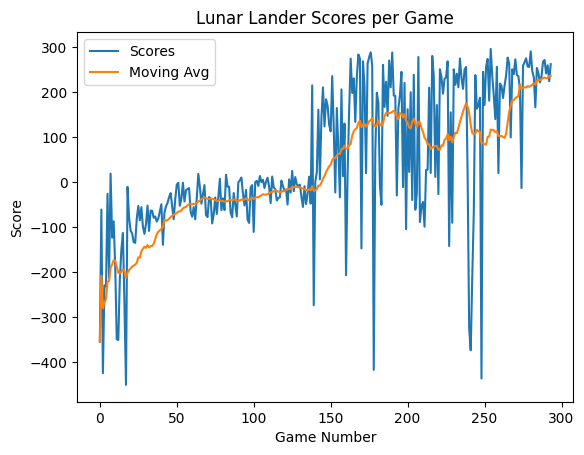

In [28]:
plt.plot(log["scores"], label="Scores")
plt.plot(log["running_avg_scores"], label="Moving Avg")
plt.title("Lunar Lander Scores per Game")
plt.xlabel("Game Number")
plt.ylabel("Score")
plt.legend()
plt.show()

Solve for moving target problem.

In [29]:
class Agent:
    def __init__(self,
                 max_memories=100_000,
                 discount_factor=0.99,
                 learning_rate=0.001,
                 input_state_features=8,
                 num_actions=4,
                 hidden_features=128,
                 epsilon=1.0,
                 epsilon_decay=0.999,
                 min_epsilon=0.05,
                 device="cpu"):

        self.max_memories = max_memories
        self.discount_factor = discount_factor
        self.learning_rate = learning_rate
        self.input_state_features = input_state_features
        self.num_actions = num_actions
        self.action_space = np.arange(self.num_actions)
        self.hidden_features = hidden_features
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.device = device

        self.DQN = DQN(self.input_state_features, self.num_actions, self.hidden_features).to(device)

        self.DQN_NEXT = DQN(self.input_state_features, self.num_actions, self.hidden_features).to(device)
        self.DQN_NEXT.load_state_dict(self.DQN.state_dict())
        self.DQN_NEXT.eval()

        self.optimizer = optim.Adam(self.DQN.parameters(), lr=self.learning_rate)
        self.loss_fn = nn.MSELoss()
        self.timecapsule = TimeCapsule(self.max_memories, self.input_state_features)

    def select_action(self, state):

        if not isinstance(state, torch.Tensor):
            state = torch.tensor(state, device=self.device)

        if state.dim() == 1:
            state = state.unsqueeze(0)

        assert state.shape[-1] == self.input_state_features, f"Passing {state.shape[-1]} features, expect {self.input_state_features}"

        if np.random.rand() < self.epsilon:
            action = np.random.choice(self.action_space)
        else:
            self.DQN.eval()
            with torch.no_grad():
                Q_s_a = self.DQN(state)
            action = torch.argmax(Q_s_a).item()
            self.DQN.train()

        return action

    def update_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

    def inference(self, state, device="cpu"):

        self.DQN = self.DQN.to(device)
        self.DQN.eval()

        with torch.no_grad():
            Q_s_a = self.DQN(state.to(device))

        return torch.argmax(Q_s_a).item()

    def update_target_network(self):
        self.DQN_NEXT.load_state_dict(self.DQN.state_dict())

    def train_step(self, batch_size):

        batch = self.timecapsule.access_memories(batch_size, self.device)

        if batch is None:
            return None

        q_estimate = self.DQN(batch["states"])  ### [B x Actions]
        q_estimate = torch.gather(q_estimate, index=batch["actions"].unsqueeze(-1), dim=-1).squeeze(-1) ###[B]

        with torch.no_grad():
            q_next_estimate = self.DQN_NEXT(batch["next_states"])  ### [B x Actions]

        max_q_next_estimate = torch.max(q_next_estimate, dim=-1).values ###[B]
        td_target = batch["rewards"] + self.discount_factor * max_q_next_estimate * (~batch["terminal"])

        loss = self.loss_fn(td_target, q_estimate)

        loss.backward()
        self.optimizer.step()
        self.optimizer.zero_grad()
        self.update_epsilon()

In [30]:
def trainer(env,
            num_games=500,
            update_target_freq=3,
            min_reward=200,
            game_tolerance=10,
            max_memories=100_000,
            discount_factor=0.99,
            learning_rate=0.001,
            batch_size=64,
            input_state_features=8,
            num_actions=4,
            hidden_features=128,
            epsilon=1.0,
            epsilon_decay=0.999,
            min_epsilon=0.05,
            log_freq=5,
            running_avg_steps=25,
            device="cpu"):

  agent = Agent(max_memories=max_memories,
                  discount_factor=discount_factor,
                  learning_rate=learning_rate,
                  input_state_features=input_state_features,
                  num_actions=num_actions,
                  hidden_features=hidden_features,
                  epsilon=epsilon,
                  epsilon_decay=epsilon_decay,
                  min_epsilon=min_epsilon,
                  device=device)

  ending_tol = 0

  log = {"scores": [], "running_avg_scores": []}

  for i in range(num_games):
        score = 0
        step = 0
        state, _ = env.reset()
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminal, truncated, _= env.step(action)
            done = terminal or truncated
            score += reward
            agent.timecapsule.add_memory(state, next_state, action, reward, done)
            agent.train_step(batch_size)

            if step % update_target_freq == 0:
                agent.update_target_network()
            step += 1

            state = next_state

        log["scores"].append(score)
        running_avg_score = np.mean(log["scores"][-running_avg_steps:])
        log["running_avg_scores"].append(running_avg_score)

        if i % log_freq == 0:
            print(f"Game #: {i} | Score: {score} | Moving Avg Scores: {running_avg_score} | Epsilon: {agent.epsilon}")

        if score >= min_reward:
            ending_tol += 1

            if ending_tol == game_tolerance:
                break
        else:
            ending_tol = 0

  print("Completed Training")
  return agent, log

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
agent, log = trainer(env, device=device)

Game #: 0 | Score: -32.64090807077443 | Moving Avg Scores: -32.64090807077443 | Epsilon: 0.997002999
Game #: 5 | Score: -376.2393481084399 | Moving Avg Scores: -229.83189684324165 | Epsilon: 0.5530559000531677
Game #: 10 | Score: -342.7920704791726 | Moving Avg Scores: -274.56822415924256 | Epsilon: 0.3074047815158953
Game #: 15 | Score: 191.14817033092976 | Moving Avg Scores: -209.12330498629933 | Epsilon: 0.07995723559482606
Game #: 20 | Score: -122.05663864689791 | Moving Avg Scores: -196.53724757888654 | Epsilon: 0.05
Game #: 25 | Score: -198.59239900609572 | Moving Avg Scores: -179.79469079420812 | Epsilon: 0.05
Game #: 30 | Score: 117.52152610213493 | Moving Avg Scores: -121.27607376683706 | Epsilon: 0.05
Game #: 35 | Score: -66.35587264982605 | Moving Avg Scores: -42.88607623668909 | Epsilon: 0.05
Game #: 40 | Score: -251.97255260815956 | Moving Avg Scores: -48.86343352049951 | Epsilon: 0.05
Game #: 45 | Score: -266.5455904377712 | Moving Avg Scores: -72.52693423475316 | Epsilon

In [36]:
record_game(env, agent, prefix="q_learning_stable")
Video("savevideos/q_learning_stable-episode-0.mp4", embed=True)

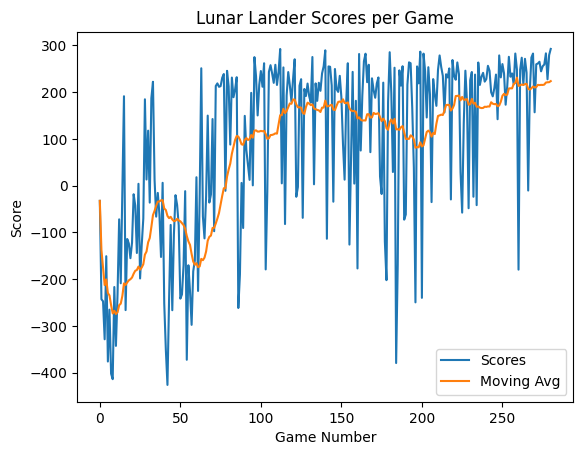

In [33]:
plt.plot(log["scores"], label="Scores")
plt.plot(log["running_avg_scores"], label="Moving Avg")
plt.title("Lunar Lander Scores per Game")
plt.xlabel("Game Number")
plt.ylabel("Score")
plt.legend()
plt.show()